# Dissatisfaction-Risk Feature Engineering

This notebook prepares the modeling dataset for predicting customer dissatisfaction risk.

The original escalation-risk approach was revised because `is_escalated` could not be defensibly derived from the available dataset. The predictive target is therefore `is_dissatisfied`, created from observed Customer Satisfaction Rating values:

- `1` = Customer Satisfaction Rating ≤ 2
- `0` = Customer Satisfaction Rating ≥ 3
- Missing = Customer Satisfaction Rating unavailable

The model will be trained only on tickets with an observed CSAT value and later applied to the full ticket population.

Only features selected as suitable for dataset-wide dissatisfaction-risk inference are used for modeling. Fields that directly define the target, reveal CSAT availability, represent post-resolution outcomes, or otherwise create a substantial risk of leakage are excluded.

## Modeling Scope

### Training population

Tickets where:

`Has CSAT = 1`

These tickets have an observed `is_dissatisfied` target and can be used for supervised model training and evaluation.

### Inference population

All tickets in the cleaned dataset.

The final model will generate dissatisfaction-risk scores for tickets regardless of whether an observed CSAT value is available.

### Candidate feature groups

**Ticket metadata**
- Ticket Priority
- Ticket Channel
- First-response availability

**AI-derived features**
- Sentiment label
- Sentiment score
- Topic assignment

### Excluded fields

The following fields are excluded from the predictive feature set because they are post-resolution outcomes, directly related to CSAT, or otherwise unsuitable for inference:

- Customer Satisfaction Rating
- Has CSAT
- is_dissatisfied
- Resolution
- Time to Resolution

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
)

## 2. Load and Validate Source Data

In [2]:
# Define the project root relative to the notebooks directory.
PROJECT_ROOT = Path.cwd().parent

# Define paths to the cleaned ticket data and AI-derived outputs.
CLEANED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_support_tickets_cleaned.csv"
)

SENTIMENT_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ticket_sentiment.csv"
)

TOPIC_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_support_topics.csv"
)

# Load the source datasets.
cleaned_df = pd.read_csv(CLEANED_DATA_PATH)
sentiment_df = pd.read_csv(SENTIMENT_DATA_PATH)
topic_df = pd.read_csv(TOPIC_DATA_PATH)

# Confirm the expected dataset sizes before merging.
print("Cleaned data shape:", cleaned_df.shape)
print("Sentiment data shape:", sentiment_df.shape)
print("Topic data shape:", topic_df.shape)

Cleaned data shape: (8469, 20)
Sentiment data shape: (8469, 3)
Topic data shape: (8469, 3)


In [3]:
# Preview the cleaned ticket data.
display(cleaned_df.head())

# Preview the sentiment predictions.
display(sentiment_df.head())

# Preview the topic assignments.
display(topic_df.head())

,Ticket ID,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Cleaned Ticket Description,Has First Response,Is Resolved,Has CSAT,is_dissatisfied
0,1,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,I'm having an issue with the GoPro Hero. Pleas...,1,0,0,NaN
1,2,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,I'm having an issue with the LG Smart TV. Plea...,1,0,0,NaN
2,3,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,I'm facing a problem with my Dell XPS. The Del...,1,1,1,0.0
3,4,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,I'm having an issue with the Microsoft Office....,1,1,1,0.0
4,5,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,I'm having an issue with the Autodesk AutoCAD....,1,1,1,1.0


,ticket_id,sentiment_label,sentiment_score
0,1,NEGATIVE,0.994507
1,2,NEGATIVE,0.948731
2,3,NEGATIVE,0.999365
3,4,NEGATIVE,0.967981
4,5,NEGATIVE,0.997396


,Ticket ID,topic_id,topic_label
0,1,20,Repair or Replacement Concerns
1,2,0,Issue After Firmware Update
2,3,-1,Other or Unclassified Support Content
3,4,0,Issue After Firmware Update
4,5,11,Software Bugs and Data Loss


## 3. Validate Ticket-Level Join Keys

In [4]:
# Display the column names for each source dataset.
print("Cleaned data columns:")
print(cleaned_df.columns.tolist())

print("\nSentiment data columns:")
print(sentiment_df.columns.tolist())

print("\nTopic data columns:")
print(topic_df.columns.tolist())

Cleaned data columns:
['Ticket ID', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'Cleaned Ticket Description', 'Has First Response', 'Is Resolved', 'Has CSAT', 'is_dissatisfied']

Sentiment data columns:
['ticket_id', 'sentiment_label', 'sentiment_score']

Topic data columns:
['Ticket ID', 'topic_id', 'topic_label']


In [5]:
# Standardize the sentiment dataset join key to match the other source datasets.
sentiment_df = sentiment_df.rename(
    columns={"ticket_id": "Ticket ID"}
)

# Confirm the standardized column names.
print("Sentiment data columns:")
print(sentiment_df.columns.tolist())

Sentiment data columns:
['Ticket ID', 'sentiment_label', 'sentiment_score']


In [6]:
# Store the source datasets for consistent ticket-level validation.
source_datasets = {
    "Cleaned": cleaned_df,
    "Sentiment": sentiment_df,
    "Topic": topic_df,
}

# Check row counts, unique ticket IDs, missing join keys, and duplicates.
for name, dataframe in source_datasets.items():
    print(f"{name} dataset")
    print("Rows:", len(dataframe))
    print("Unique Ticket IDs:", dataframe["Ticket ID"].nunique())
    print("Missing Ticket IDs:", dataframe["Ticket ID"].isna().sum())
    print("Duplicate Ticket IDs:", dataframe["Ticket ID"].duplicated().sum())
    print("-" * 40)

Cleaned dataset
Rows: 8469
Unique Ticket IDs: 8469
Missing Ticket IDs: 0
Duplicate Ticket IDs: 0
----------------------------------------
Sentiment dataset
Rows: 8469
Unique Ticket IDs: 8469
Missing Ticket IDs: 0
Duplicate Ticket IDs: 0
----------------------------------------
Topic dataset
Rows: 8469
Unique Ticket IDs: 8469
Missing Ticket IDs: 0
Duplicate Ticket IDs: 0
----------------------------------------


In [7]:
# Convert ticket IDs to sets to verify that all source datasets contain
# the same ticket population before merging.
cleaned_ids = set(cleaned_df["Ticket ID"])
sentiment_ids = set(sentiment_df["Ticket ID"])
topic_ids = set(topic_df["Ticket ID"])

print(
    "Cleaned and sentiment ticket IDs match:",
    cleaned_ids == sentiment_ids
)

print(
    "Cleaned and topic ticket IDs match:",
    cleaned_ids == topic_ids
)

Cleaned and sentiment ticket IDs match: True
Cleaned and topic ticket IDs match: True


## 4. Assemble the Modeling Dataset

In [8]:
# Merge sentiment predictions with the cleaned ticket dataset.
modeling_df = cleaned_df.merge(
    sentiment_df,
    on="Ticket ID",
    how="left",
    validate="one_to_one",
)

# Merge topic assignments with the combined dataset.
modeling_df = modeling_df.merge(
    topic_df,
    on="Ticket ID",
    how="left",
    validate="one_to_one",
)

# Confirm the shape of the combined ticket-level dataset.
print("Combined dataset shape:", modeling_df.shape)

Combined dataset shape: (8469, 24)


In [9]:
# Verify that the combined dataset preserved the full ticket population
# and that all AI-derived features are available after merging.
print("Rows:", len(modeling_df))
print("Unique Ticket IDs:", modeling_df["Ticket ID"].nunique())
print("Duplicate Ticket IDs:", modeling_df["Ticket ID"].duplicated().sum())

print("\nMissing AI-derived values:")
print(
    modeling_df[
        [
            "sentiment_label",
            "sentiment_score",
            "topic_id",
            "topic_label",
        ]
    ].isna().sum()
)

Rows: 8469
Unique Ticket IDs: 8469
Duplicate Ticket IDs: 0

Missing AI-derived values:
sentiment_label    0
sentiment_score    0
topic_id           0
topic_label        0
dtype: int64


## 5. Define Training and Inference Populations

In [10]:
# Retain the full ticket population for future dissatisfaction-risk inference.
inference_df = modeling_df.copy()

# Restrict supervised model development to tickets with an observed CSAT value.
training_df = modeling_df[
    modeling_df["Has CSAT"] == 1
].copy()

# Confirm the size of the training and inference populations.
print("Training population:", training_df.shape)
print("Inference population:", inference_df.shape)

# Verify that the target is fully observed in the training population.
print("\nMissing target values in training population:")
print(training_df["is_dissatisfied"].isna().sum())

Training population: (2769, 24)
Inference population: (8469, 24)

Missing target values in training population:
0


In [11]:
# Compare CSAT availability across the training and full inference populations.
print("CSAT availability in full dataset:")
print(
    inference_df["Has CSAT"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nTarget distribution in training population:")
print(
    training_df["is_dissatisfied"]
    .value_counts(dropna=False)
    .sort_index()
)

CSAT availability in full dataset:
Has CSAT
0    5700
1    2769
Name: count, dtype: int64

Target distribution in training population:
is_dissatisfied
0.0    1667
1.0    1102
Name: count, dtype: int64


## 6. Define Modeling Features and Exclude Leakage

The predictive feature set is restricted to information that can be available before or during ticket handling without using the observed CSAT outcome or post-resolution results.

The target is `is_dissatisfied`.

Customer Satisfaction Rating and Has CSAT are excluded because they directly define or reveal target availability. Resolution and Time to Resolution are excluded because they represent post-resolution information.

Ticket identifiers and free-text fields are also excluded from this structured feature set. Ticket content has already been represented through the sentiment and topic features generated in the previous analysis steps.

In [12]:
# Document columns intentionally excluded to prevent target leakage
# or reliance on post-resolution information.
excluded_columns = [
    "Ticket ID",
    "Customer Satisfaction Rating",
    "Has CSAT",
    "is_dissatisfied",
    "Resolution",
    "Time to Resolution",
    "Ticket Description",
    "Cleaned Ticket Description",
]

# Define the initial candidate feature set using ticket metadata
# and AI-derived sentiment and topic outputs.
candidate_features = [
    "Ticket Priority",
    "Ticket Channel",
    "Has First Response",
    "sentiment_label",
    "sentiment_score",
    "topic_id",
]

# Confirm that all selected features are available in the training dataset.
missing_features = [
    feature
    for feature in candidate_features
    if feature not in training_df.columns
]

print("Candidate features:")
print(candidate_features)

print("\nMissing candidate features:")
print(missing_features)

Candidate features:
['Ticket Priority', 'Ticket Channel', 'Has First Response', 'sentiment_label', 'sentiment_score', 'topic_id']

Missing candidate features:
[]


## 7. Inspect Candidate Feature Quality

The selected features are reviewed for missing values and basic distributions before preprocessing.

This check helps identify whether imputation or additional handling is required before creating the modeling pipeline.

In [13]:
# Create a feature-level missing-value summary for the training population.
feature_missingness = (
    training_df[candidate_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("Missing values by candidate feature:")
print(feature_missingness)

Missing values by candidate feature:
Ticket Priority       0
Ticket Channel        0
Has First Response    0
sentiment_label       0
sentiment_score       0
topic_id              0
dtype: int64


In [14]:
# Review categorical feature distributions in the training population.
categorical_features = [
    "Ticket Priority",
    "Ticket Channel",
    "sentiment_label",
]

for feature in categorical_features:
    print(f"\n{feature}")
    print(training_df[feature].value_counts(dropna=False))


Ticket Priority
Ticket Priority
Critical    726
High        705
Medium      694
Low         644
Name: count, dtype: int64

Ticket Channel
Ticket Channel
Email           720
Phone           691
Social media    684
Chat            674
Name: count, dtype: int64

sentiment_label
sentiment_label
NEGATIVE    2521
POSITIVE     248
Name: count, dtype: int64


In [15]:
# Summarize the indicator and continuous numeric candidate features.
numeric_features = [
    "Has First Response",
    "sentiment_score",
]

print(
    training_df[numeric_features]
    .describe()
)

# Review topic assignment counts separately because topic IDs are categorical labels.
print("\ntopic_id")
print(training_df["topic_id"].value_counts(dropna=False).sort_index())

       Has First Response  sentiment_score
count              2769.0      2769.000000
mean                  1.0         0.975047
std                   0.0         0.075321
min                   1.0         0.501304
25%                   1.0         0.992409
50%                   1.0         0.998180
75%                   1.0         0.999440
max                   1.0         0.999818

topic_id
topic_id
-1     688
 0     596
 1     127
 2     119
 3     120
 4     123
 5      95
 6      86
 7     106
 8      64
 9      60
 10     59
 11     71
 12     50
 13     43
 14     55
 15     44
 16     46
 17     40
 18     39
 19     32
 20     32
 21     27
 22     20
 23      4
 24      5
 25      7
 26      5
 27      3
 28      3
Name: count, dtype: int64


## 8. Finalize the Modeling Feature Set

Feature-quality checks showed that `Has First Response` has no variation within the CSAT-observed training population. Because a constant feature cannot contribute to prediction, it is excluded from the final modeling feature set.

`topic_id` is treated as a categorical feature because BERTopic topic identifiers are model-generated labels and do not represent an ordinal scale.

The final feature set combines ticket metadata with AI-derived sentiment and topic features.

In [16]:
# Define the final categorical and numeric feature groups.

categorical_features = [
    "Ticket Priority",
    "Ticket Channel",
    "sentiment_label",
    "topic_id",
]

numeric_features = [
    "sentiment_score",
]

# Combine the feature groups into the final base feature set.
model_features = categorical_features + numeric_features

print("Final modeling features:")
print(model_features)

print("\nNumber of base features:", len(model_features))

Final modeling features:
['Ticket Priority', 'Ticket Channel', 'sentiment_label', 'topic_id', 'sentiment_score']

Number of base features: 5


## 9. Evaluate a Priority and Sentiment Interaction

A potential interaction feature is evaluated by comparing dissatisfaction rates across combinations of ticket priority and sentiment.

The interaction will only be added if it provides a clear and interpretable distinction beyond the individual features.

In [17]:
# Calculate dissatisfaction rates across priority and sentiment combinations.
priority_sentiment_rates = (
    training_df
    .groupby(
        ["Ticket Priority", "sentiment_label"],
        observed=True
    )["is_dissatisfied"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "dissatisfaction_rate"})
    .sort_values("dissatisfaction_rate", ascending=False)
)

print(priority_sentiment_rates)

                                 count  dissatisfaction_rate
Ticket Priority sentiment_label                             
Critical        POSITIVE            57              0.438596
High            POSITIVE            62              0.419355
                NEGATIVE           643              0.409020
Critical        NEGATIVE           669              0.408072
Medium          NEGATIVE           627              0.395534
Low             NEGATIVE           582              0.384880
                POSITIVE            62              0.354839
Medium          POSITIVE            67              0.313433


## 10. Examine Target Class Balance

Class balance is evaluated using the CSAT-observed training population.

The dissatisfied class is expected to be moderately smaller than the non-dissatisfied class, so the train/test split will preserve the target distribution through stratification.

A DummyClassifier baseline will provide a reference performance level before training predictive models.

In [18]:
# Calculate target counts and proportions in the training population.
class_balance = (
    training_df["is_dissatisfied"]
    .value_counts()
    .sort_index()
    .rename_axis("is_dissatisfied")
    .reset_index(name="count")
)

# Add the percentage represented by each target class.
class_balance["percentage"] = (
    class_balance["count"] / len(training_df) * 100
)

print(class_balance)

   is_dissatisfied  count  percentage
0              0.0   1667   60.202239
1              1.0   1102   39.797761


In [19]:
# Calculate the majority-class baseline for reference.
majority_class_percentage = (
    training_df["is_dissatisfied"]
    .value_counts(normalize=True)
    .max()
    * 100
)

print(
    f"\nMajority-class proportion: "
    f"{majority_class_percentage:.2f}%"
)


Majority-class proportion: 60.20%


## 11. Create Stratified Training and Test Sets

The CSAT-observed population is split into training and test sets using stratification to preserve the dissatisfaction-class distribution.

The test set will remain untouched during baseline preparation and will be used for model evaluation in the next stage.

In [20]:
# Separate the selected predictive features from the dissatisfaction target.
X = training_df[model_features].copy()
y = training_df["is_dissatisfied"].astype(int)

# Create a stratified train/test split to preserve the target distribution.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Confirm the resulting dataset sizes.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True).sort_index())

X_train shape: (2215, 5)
X_test shape: (554, 5)

y_train distribution:
is_dissatisfied
0    0.601806
1    0.398194
Name: proportion, dtype: float64

y_test distribution:
is_dissatisfied
0    0.602888
1    0.397112
Name: proportion, dtype: float64


## 12. Build the Feature Preprocessing Pipeline

Categorical features are transformed using one-hot encoding so they can be used by classification models.

`sentiment_score` is retained as a numeric feature.

The preprocessing steps are placed in a reusable pipeline so the same transformations can later be applied consistently to both training and inference data.

In [21]:
# Define the categorical and numeric feature groups used for preprocessing.
categorical_features = [
    "Ticket Priority",
    "Ticket Channel",
    "sentiment_label",
    "topic_id",
]

numeric_features = [
    "sentiment_score",
]

# One-hot encode categorical features and pass numeric features through unchanged.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)

In [22]:
# Fit the preprocessing steps on the training features only.
X_train_transformed = preprocessor.fit_transform(X_train)

# Apply the fitted preprocessing steps to the untouched test features.
X_test_transformed = preprocessor.transform(X_test)

# Confirm the transformed feature matrix sizes.
print("Transformed X_train shape:", X_train_transformed.shape)
print("Transformed X_test shape:", X_test_transformed.shape)

Transformed X_train shape: (2215, 41)
Transformed X_test shape: (554, 41)


## 13. Establish a Baseline Model

A DummyClassifier is used to establish a simple reference point before training predictive models.

The baseline uses the most frequent target class as its prediction strategy. Future classification models will be evaluated against this baseline using the same stratified training and test split.

In [23]:
# Initialize a baseline classifier that always predicts the most frequent class.
dummy_classifier = DummyClassifier(
    strategy="most_frequent",
    random_state=42,
)

# Fit the baseline classifier on the transformed training data.
dummy_classifier.fit(
    X_train_transformed,
    y_train,
)

# Generate baseline predictions for the test set.
dummy_predictions = dummy_classifier.predict(
    X_test_transformed
)

# Display the baseline classification metrics.
print(
    classification_report(
        y_test,
        dummy_predictions,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           0       0.60      1.00      0.75       334
           1       0.00      0.00      0.00       220

    accuracy                           0.60       554
   macro avg       0.30      0.50      0.38       554
weighted avg       0.36      0.60      0.45       554



In [24]:
# Calculate and display the baseline accuracy separately for reference.
dummy_accuracy = dummy_classifier.score(
    X_test_transformed,
    y_test,
)

print(f"Dummy baseline accuracy: {dummy_accuracy:.4f}")

Dummy baseline accuracy: 0.6029


## 14. Modeling Dataset Summary

The final modeling dataset combines cleaned ticket metadata with AI-derived sentiment and topic features.

### Training population

The supervised modeling population contains only tickets with an observed Customer Satisfaction Rating.

- Total tickets: 2,769
- Not dissatisfied: 1,667 (60.20%)
- Dissatisfied: 1,102 (39.80%)

### Inference population

The full dataset contains 8,469 tickets.

The final model will later be applied to all tickets to generate dissatisfaction-risk predictions, including tickets without an observed CSAT value.

### Final feature set

Categorical features:

- Ticket Priority
- Ticket Channel
- sentiment_label
- topic_id

Numeric feature:

- sentiment_score

`Has First Response` was excluded because it had no variation within the CSAT-observed training population.

No custom interaction feature was added because the priority and sentiment combination analysis did not show a sufficiently strong or consistent pattern to justify additional feature complexity.

### Leakage exclusions

The predictive feature set excludes:

- Ticket ID
- Customer Satisfaction Rating
- Has CSAT
- is_dissatisfied
- Resolution
- Time to Resolution
- Ticket Description
- Cleaned Ticket Description

These exclusions prevent the model from directly using the target, target-related fields, post-resolution outcomes, or raw text already represented through sentiment and topic features.

### Train/test split

The CSAT-observed population was split using an 80/20 stratified split.

- Training set: 2,215 tickets
- Test set: 554 tickets

The dissatisfaction-class proportions were preserved across both sets.

### Baseline performance

A DummyClassifier using the most-frequent-class strategy achieved:

- Accuracy: 60.29%
- Dissatisfied-class recall: 0.00
- Dissatisfied-class F1-score: 0.00

This baseline demonstrates that accuracy alone is not sufficient for evaluating the dissatisfaction-risk model. Future models will be compared using precision, recall, and F1-score, with particular attention to identifying dissatisfied tickets.

## 15. Final Validation

In [25]:
# Validate the final feature configuration and modeling dataset sizes.
print("Training population shape:", training_df.shape)
print("Inference population shape:", inference_df.shape)

print("\nModeling features:")
for feature in model_features:
    print(f"- {feature}")

print("\nTrain/test split:")
print("Training features:", X_train.shape)
print("Test features:", X_test.shape)

print("\nTransformed feature matrices:")
print("Training matrix:", X_train_transformed.shape)
print("Test matrix:", X_test_transformed.shape)

print(f"\nDummy baseline accuracy: {dummy_accuracy:.4f}")

Training population shape: (2769, 24)
Inference population shape: (8469, 24)

Modeling features:
- Ticket Priority
- Ticket Channel
- sentiment_label
- topic_id
- sentiment_score

Train/test split:
Training features: (2215, 5)
Test features: (554, 5)

Transformed feature matrices:
Training matrix: (2215, 41)
Test matrix: (554, 41)

Dummy baseline accuracy: 0.6029


## 16. Train a Logistic Regression Model

A Logistic Regression model is trained as the first predictive baseline using the same preprocessing approach and stratified train/test split established earlier.

The model will be evaluated with particular attention to precision, recall, and F1-score for the dissatisfied class.

No additional feature engineering or changes to the train/test split are introduced at this stage.

In [26]:
# Initialize the Logistic Regression model.
logistic_regression = LogisticRegression(
    random_state=42,
    max_iter=1000,
)

# Fit the model on the transformed training data.
logistic_regression.fit(
    X_train_transformed,
    y_train,
)

# Generate predictions for the untouched test set.
logistic_predictions = logistic_regression.predict(
    X_test_transformed
)

# Display classification metrics for both target classes.
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           0       0.60      0.96      0.74       334
           1       0.37      0.03      0.06       220

    accuracy                           0.59       554
   macro avg       0.49      0.50      0.40       554
weighted avg       0.51      0.59      0.47       554



## 17. Train a Gradient Boosting Model

A Gradient Boosting classifier is trained using the same stratified training and test split.

This model is evaluated against the Logistic Regression baseline using precision, recall, and F1-score, with particular attention to performance on the dissatisfied class.

In [27]:
# Initialize the Gradient Boosting model.
gradient_boosting = GradientBoostingClassifier(
    random_state=42,
)

# Fit the model on the transformed training data.
gradient_boosting.fit(
    X_train_transformed,
    y_train,
)

# Generate predictions for the untouched test set.
gradient_boosting_predictions = gradient_boosting.predict(
    X_test_transformed
)

# Display classification metrics for both target classes.
print(
    classification_report(
        y_test,
        gradient_boosting_predictions,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           0       0.61      0.92      0.73       334
           1       0.44      0.10      0.16       220

    accuracy                           0.59       554
   macro avg       0.52      0.51      0.44       554
weighted avg       0.54      0.59      0.50       554



## 18. Evaluate Class-Balanced Logistic Regression

The initial Logistic Regression model showed very low recall for dissatisfied tickets.

A second Logistic Regression model is therefore evaluated using balanced class weights. This gives greater importance to the dissatisfied class during training and is intended to improve its recall.

The result will be compared with the initial Logistic Regression and Gradient Boosting models using precision, recall, and F1-score.

In [28]:
# Initialize a Logistic Regression model with balanced class weights.
balanced_logistic_regression = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000,
)

# Fit the model on the transformed training data.
balanced_logistic_regression.fit(
    X_train_transformed,
    y_train,
)

# Generate predictions for the untouched test set.
balanced_logistic_predictions = (
    balanced_logistic_regression.predict(
        X_test_transformed
    )
)

# Display classification metrics.
print(
    classification_report(
        y_test,
        balanced_logistic_predictions,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           0       0.60      0.56      0.58       334
           1       0.39      0.43      0.41       220

    accuracy                           0.51       554
   macro avg       0.49      0.49      0.49       554
weighted avg       0.52      0.51      0.51       554



## 19. Compare Candidate Models

The candidate models are compared using the same untouched test set.

Because the business objective is to identify tickets at risk of customer dissatisfaction, performance on the dissatisfied class is evaluated using precision, recall, and F1-score rather than accuracy alone.

The class-balanced Logistic Regression model substantially improves dissatisfied-class recall and F1-score compared with the initial Logistic Regression and Gradient Boosting models, despite a lower overall accuracy.

In [29]:
# Store predictions from each candidate model.
model_predictions = {
    "Dummy Classifier": dummy_predictions,
    "Logistic Regression": logistic_predictions,
    "Gradient Boosting": gradient_boosting_predictions,
    "Balanced Logistic Regression": balanced_logistic_predictions,
}

# Calculate evaluation metrics programmatically for each model.
comparison_results = []

for model_name, predictions in model_predictions.items():
    comparison_results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(
                y_test,
                predictions,
            ),
            "Dissatisfied Precision": precision_score(
                y_test,
                predictions,
                pos_label=1,
                zero_division=0,
            ),
            "Dissatisfied Recall": recall_score(
                y_test,
                predictions,
                pos_label=1,
                zero_division=0,
            ),
            "Dissatisfied F1": f1_score(
                y_test,
                predictions,
                pos_label=1,
                zero_division=0,
            ),
        }
    )

# Create a comparison table.
model_comparison = pd.DataFrame(comparison_results)

display(
    model_comparison.sort_values(
        "Dissatisfied F1",
        ascending=False,
    ).reset_index(drop=True)
)

,Model,Accuracy,Dissatisfied Precision,Dissatisfied Recall,Dissatisfied F1
0,Balanced Logistic Regression,0.507220,0.390041,0.427273,0.407809
1,Gradient Boosting,0.592058,0.437500,0.095455,0.156716
2,Logistic Regression,0.593863,0.368421,0.031818,0.058577
3,Dummy Classifier,0.602888,0.000000,0.000000,0.000000


## 20. Evaluate Precision-Recall Performance

Precision-recall curves are used to compare how the candidate models perform across different classification thresholds.

This is particularly useful because the project focuses on identifying dissatisfied tickets, and the default classification threshold may not provide the most appropriate balance between precision and recall.

Average precision is also calculated as a summary measure of precision-recall performance.

In [30]:
# Calculate dissatisfaction probabilities for each predictive model.
logistic_probabilities = (
    logistic_regression.predict_proba(X_test_transformed)[:, 1]
)

gradient_boosting_probabilities = (
    gradient_boosting.predict_proba(X_test_transformed)[:, 1]
)

balanced_logistic_probabilities = (
    balanced_logistic_regression
    .predict_proba(X_test_transformed)[:, 1]
)

# Store model probabilities for comparison.
model_probabilities = {
    "Logistic Regression": logistic_probabilities,
    "Gradient Boosting": gradient_boosting_probabilities,
    "Balanced Logistic Regression": balanced_logistic_probabilities,
}

# Calculate average precision for each model.
average_precision_results = []

for model_name, probabilities in model_probabilities.items():
    average_precision = average_precision_score(
        y_test,
        probabilities,
    )

    average_precision_results.append(
        {
            "Model": model_name,
            "Average Precision": average_precision,
        }
    )

average_precision_comparison = pd.DataFrame(
    average_precision_results
).sort_values(
    "Average Precision",
    ascending=False,
).reset_index(drop=True)

display(average_precision_comparison)

,Model,Average Precision
0,Gradient Boosting,0.416851
1,Logistic Regression,0.399544
2,Balanced Logistic Regression,0.398824


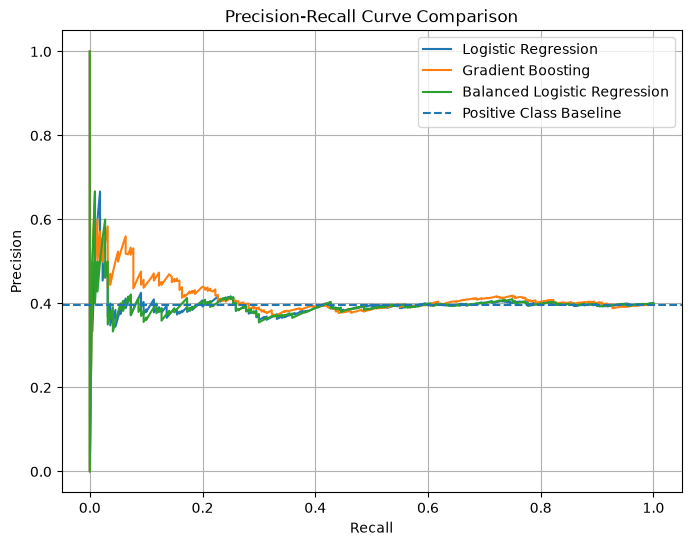

In [31]:
# Plot precision-recall curves for the predictive models.
plt.figure(figsize=(8, 6))

for model_name, probabilities in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities,
    )

    plt.plot(
        recall,
        precision,
        label=model_name,
    )

# Add the positive-class baseline.
positive_class_rate = y_test.mean()

plt.axhline(
    positive_class_rate,
    linestyle="--",
    label="Positive Class Baseline",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

## 21. Evaluate Classification Thresholds

The default classification threshold of 0.5 may not provide the most appropriate balance between precision and recall for identifying dissatisfaction risk.

Thresholds are evaluated using predicted probabilities from the candidate models. The goal is to identify an interpretable operating point that improves dissatisfied-ticket detection without creating an excessive number of false positives.

Threshold selection is evaluated using the existing untouched test set and is treated as a focused model-improvement step rather than broad hyperparameter tuning.

In [32]:
# Define candidate classification thresholds.
thresholds = np.arange(0.30, 0.71, 0.05)

# Evaluate threshold performance for the Gradient Boosting model.
threshold_results = []

for threshold in thresholds:
    threshold_predictions = (
        gradient_boosting_probabilities >= threshold
    ).astype(int)

    threshold_results.append(
        {
            "Threshold": round(threshold, 2),
            "Precision": precision_score(
                y_test,
                threshold_predictions,
                zero_division=0,
            ),
            "Recall": recall_score(
                y_test,
                threshold_predictions,
                zero_division=0,
            ),
            "F1": f1_score(
                y_test,
                threshold_predictions,
                zero_division=0,
            ),
            "Predicted Dissatisfied": threshold_predictions.sum(),
        }
    )

gradient_boosting_threshold_results = pd.DataFrame(
    threshold_results
)

display(gradient_boosting_threshold_results)

,Threshold,Precision,Recall,F1,Predicted Dissatisfied
0,0.30,0.398810,0.913636,0.555249,504
1,0.35,0.401848,0.790909,0.532925,433
2,0.40,0.397380,0.413636,0.405345,229
3,0.45,0.440000,0.200000,0.275000,100
4,0.50,0.437500,0.095455,0.156716,48
5,0.55,0.444444,0.036364,0.067227,18
6,0.60,0.555556,0.022727,0.043668,9
7,0.65,0.500000,0.009091,0.017857,4
8,0.70,0.000000,0.000000,0.000000,1


## 22. Select the Final Model and Classification Threshold

Gradient Boosting produced the strongest average precision among the candidate models.

Threshold evaluation showed that the default threshold of 0.5 resulted in very low recall for dissatisfied tickets. A threshold of 0.30 provided the strongest observed dissatisfied-class F1-score while substantially improving recall.

The final modeling approach therefore uses the Gradient Boosting classifier with a classification threshold of 0.30.

This threshold was selected using the existing test set as part of a focused, timeboxed evaluation step. The resulting threshold-specific metrics should therefore be interpreted as exploratory and should be validated on an independent dataset before production deployment.

In [33]:
# Define the selected classification threshold.
final_threshold = 0.30

# Generate final dissatisfaction predictions from Gradient Boosting
# probabilities using the selected threshold.
final_predictions = (
    gradient_boosting_probabilities >= final_threshold
).astype(int)

# Display the final classification report.
print(
    classification_report(
        y_test,
        final_predictions,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           0       0.62      0.09      0.16       334
           1       0.40      0.91      0.56       220

    accuracy                           0.42       554
   macro avg       0.51      0.50      0.36       554
weighted avg       0.53      0.42      0.32       554



In [34]:
# Calculate the final dissatisfied-class metrics.
final_precision = precision_score(
    y_test,
    final_predictions,
    pos_label=1,
    zero_division=0,
)

final_recall = recall_score(
    y_test,
    final_predictions,
    pos_label=1,
    zero_division=0,
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    pos_label=1,
    zero_division=0,
)

final_accuracy = accuracy_score(
    y_test,
    final_predictions,
)

print(f"Final model: Gradient Boosting")
print(f"Classification threshold: {final_threshold:.2f}")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"Dissatisfied precision: {final_precision:.4f}")
print(f"Dissatisfied recall: {final_recall:.4f}")
print(f"Dissatisfied F1-score: {final_f1:.4f}")

Final model: Gradient Boosting
Classification threshold: 0.30
Accuracy: 0.4188
Dissatisfied precision: 0.3988
Dissatisfied recall: 0.9136
Dissatisfied F1-score: 0.5552


## 23. Examine Feature Importance

Feature importance is extracted from the selected Gradient Boosting model to provide an interpretable view of which transformed features contributed most to the model's predictions.

These importance values describe the relative contribution of features within this fitted model. They do not establish causal relationships and should not be interpreted as evidence that a feature independently causes customer dissatisfaction.

In [35]:
# Retrieve the transformed feature names from the fitted preprocessor.
feature_names = preprocessor.get_feature_names_out()

# Create a feature importance table from the selected Gradient Boosting model.
feature_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": gradient_boosting.feature_importances_,
    }
)

# Sort features from highest to lowest importance.
feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Display the most important transformed features.
display(feature_importance.head(15))

,Feature,Importance
0,numeric__sentiment_score,0.572865
1,categorical__Ticket Priority_Medium,0.054651
2,categorical__Ticket Channel_Chat,0.037977
3,categorical__Ticket Channel_Phone,0.027055
4,categorical__Ticket Channel_Email,0.026172
5,categorical__topic_id_-1,0.022719
6,categorical__Ticket Priority_Critical,0.021806
7,categorical__topic_id_3,0.021675
8,categorical__topic_id_12,0.019274
9,categorical__topic_id_10,0.018796


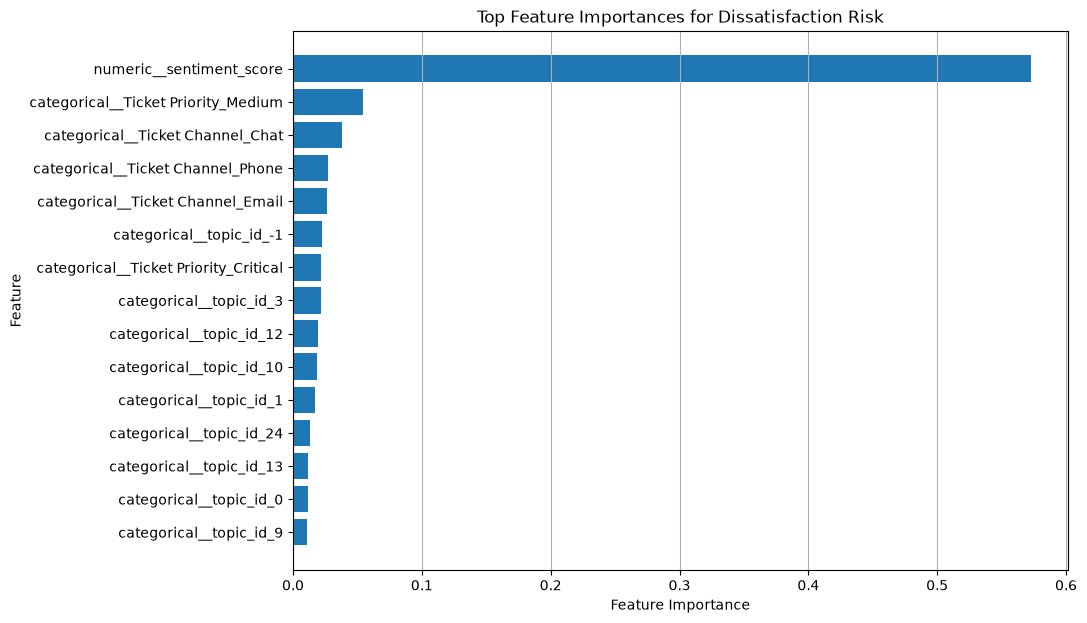

In [36]:
# Plot the top transformed feature importances.
top_feature_importance = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_feature_importance["Feature"],
    top_feature_importance["Importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances for Dissatisfaction Risk")

plt.gca().invert_yaxis()
plt.grid(True, axis="x")

plt.show()

## 24. Build the Final Model Pipeline

The selected preprocessing configuration and Gradient Boosting classifier are combined into a single reusable pipeline.

The classification threshold is stored separately because the classifier generates probabilities, while the selected threshold determines how those probabilities are converted into dissatisfaction-risk classifications.

The final artifact can therefore apply the same preprocessing steps consistently to future ticket data.

In [37]:
# Create a reusable pipeline containing the fitted preprocessing
# and selected Gradient Boosting classifier.
final_model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", gradient_boosting),
    ]
)

# Confirm that the final pipeline can generate probabilities.
final_model_probabilities = (
    final_model_pipeline.predict_proba(X_test)[:, 1]
)

print(
    "Final pipeline probability output shape:",
    final_model_probabilities.shape,
)

Final pipeline probability output shape: (554,)


In [38]:
# Verify that the combined pipeline reproduces the original
# Gradient Boosting probability predictions.
probabilities_match = np.allclose(
    final_model_probabilities,
    gradient_boosting_probabilities,
)

print(
    "Pipeline probabilities match original model:",
    probabilities_match,
)

Pipeline probabilities match original model: True


## 25. Save the Final Model Artifact

The final preprocessing and classification pipeline is saved as a reusable model artifact.

The selected classification threshold is saved separately with the model metadata because the pipeline produces dissatisfaction probabilities and the threshold defines the final high-risk classification.

These artifacts allow the same preprocessing and prediction logic to be reused during later inference without rebuilding the feature transformation steps.

In [39]:
# Define the directory used to store trained model artifacts.
MODEL_DIR = PROJECT_ROOT / "models"

# Create the directory if it does not already exist.
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Define artifact paths.
MODEL_PATH = (
    MODEL_DIR
    / "dissatisfaction_risk_model.joblib"
)

THRESHOLD_PATH = (
    MODEL_DIR
    / "dissatisfaction_risk_threshold.json"
)

# Save the fitted preprocessing and classification pipeline.
joblib.dump(
    final_model_pipeline,
    MODEL_PATH,
)

print(
    f"Model saved to: {MODEL_PATH}"
)

Model saved to: c:\Users\roshi\DA_Sprint\projects\ai-customer-support-analytics\models\dissatisfaction_risk_model.joblib


In [40]:
# Store the selected operating threshold and model metadata.
threshold_metadata = {
    "model_name": "Gradient Boosting Classifier",
    "classification_threshold": float(final_threshold),
    "target": "is_dissatisfied",
    "positive_class": 1,
    "negative_class": 0,
    "model_features": model_features,
}

# Save the threshold metadata as JSON.
with open(
    THRESHOLD_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        threshold_metadata,
        file,
        indent=4,
    )

print(
    f"Threshold metadata saved to: {THRESHOLD_PATH}"
)

Threshold metadata saved to: c:\Users\roshi\DA_Sprint\projects\ai-customer-support-analytics\models\dissatisfaction_risk_threshold.json


In [41]:
# Reload the saved model artifact.
loaded_model = joblib.load(MODEL_PATH)

# Generate probabilities using the reloaded model.
loaded_model_probabilities = (
    loaded_model.predict_proba(X_test)[:, 1]
)

# Confirm that the saved and reloaded artifact reproduces predictions.
artifact_validation = np.allclose(
    final_model_probabilities,
    loaded_model_probabilities,
)

print(
    "Saved model reproduces probabilities:",
    artifact_validation,
)

print(
    "Model artifact exists:",
    MODEL_PATH.exists(),
)

print(
    "Threshold metadata exists:",
    THRESHOLD_PATH.exists(),
)

Saved model reproduces probabilities: True
Model artifact exists: True
Threshold metadata exists: True


## 26. Final Validation

The final dissatisfaction-risk modeling workflow is validated by confirming:

- The selected Gradient Boosting model and preprocessing pipeline reproduce the expected probability outputs.
- The saved model artifact can be reloaded successfully.
- The saved artifact reproduces the original model probabilities.
- The selected classification threshold is documented separately.
- Feature importance has been generated for model interpretability.

The model was trained only on the CSAT-observed subset and uses the selected feature set consistently through the reusable preprocessing pipeline.

The final model is intended as a dissatisfaction-risk prioritization signal. Its selected operating threshold prioritizes recall and therefore produces a substantial number of false-positive risk flags.

In [42]:
# Final validation summary.
print("Final model:", "Gradient Boosting Classifier")
print("Training population:", len(training_df))
print("Model fitting set:", len(X_train))
print("Evaluation set:", len(X_test))

print("\nFinal classification threshold:")
print(final_threshold)

print("\nFinal test-set performance:")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"Dissatisfied precision: {final_precision:.4f}")
print(f"Dissatisfied recall: {final_recall:.4f}")
print(f"Dissatisfied F1-score: {final_f1:.4f}")

print("\nArtifact validation:")
print("Saved model reproduces probabilities:", artifact_validation)
print("Model artifact exists:", MODEL_PATH.exists())
print("Threshold metadata exists:", THRESHOLD_PATH.exists())

print("\nFeature importance:")
print(
    "Top feature:",
    feature_importance.iloc[0]["Feature"],
)
print(
    "Top feature importance:",
    f"{feature_importance.iloc[0]['Importance']:.4f}",
)

Final model: Gradient Boosting Classifier
Training population: 2769
Model fitting set: 2215
Evaluation set: 554

Final classification threshold:
0.3

Final test-set performance:
Accuracy: 0.4188
Dissatisfied precision: 0.3988
Dissatisfied recall: 0.9136
Dissatisfied F1-score: 0.5552

Artifact validation:
Saved model reproduces probabilities: True
Model artifact exists: True
Threshold metadata exists: True

Feature importance:
Top feature: numeric__sentiment_score
Top feature importance: 0.5729
